<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Transition_Response_Emission_Kernel_V16_CLEAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ECSM Electron-Like Packet — Time-Dependent Transition Response and Emission-Kernel Diagnostics V16

**Purpose:** extend the V15c operator-amplitude result into a finite-response transition-rate and relaxation-dynamics test.

V15c showed:

\[
M_{if}=\langle f|T|i\rangle,\qquad S_{if}=|M_{if}|^2
\]

V16 asks whether those operator-derived strengths can drive a coherence-gated transition-rate kernel,

\[
\Gamma_{if}=S_{if}\,K(\Delta E,\chi,\epsilon,\tau_{\rm resp}),
\]

and whether a finite transition network conserves probability while relaxing excited population into lower response shells.

## Expected final verdict

`PASS: ECSM bound shells support coherence-gated transition-rate kernels and finite-response relaxation diagnostics.`


In [1]:

# ============================================================
# CELL 1 — imports, run controls, and output directory
# ============================================================

import os, json, math, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_LABEL = "V16_time_dependent_transition_response_emission_kernel"
OUTDIR = Path("ecsm_electron_like_transition_response_emission_kernel_v16_out")
OUTDIR.mkdir(parents=True, exist_ok=True)

MAIN_EPSILON = 0.01
MAIN_CHI = 1.0
COHERENT_EPS_MAX = 0.01
COHERENT_CHI_MIN = 0.80

# Rate-kernel controls.  These are dimensionless response-kernel powers,
# not physical oscillator-strength calibrations.
RATE_GAP_POWER = 3.0
RATE_CHI_POWER = 2.0
TAU_RESP_0 = 1.0
RATE_SCALE = 0.20
DT = 0.05
N_STEPS = 240

ZIP_OUTPUT = True

print("Run label:", RUN_LABEL)
print("Main epsilon:", MAIN_EPSILON)
print("Main chi:", MAIN_CHI)
print("Coherent epsilon max:", COHERENT_EPS_MAX)
print("Coherent chi min:", COHERENT_CHI_MIN)
print("Output directory:", OUTDIR)


Run label: V16_time_dependent_transition_response_emission_kernel
Main epsilon: 0.01
Main chi: 1.0
Coherent epsilon max: 0.01
Coherent chi min: 0.8
Output directory: ecsm_electron_like_transition_response_emission_kernel_v16_out


In [2]:

# ============================================================
# CELL 2 — inherited fixed packet and alpha/beta closure
# ============================================================

packet = {
    "N_plus": 0.0009716378827065886,
    "N_zero": 1.000146008084612,
    "N_minus": 2.998882354032682,
    "q_eff": -0.9993035720499918,
    "R_rms": 5.236462555204353,
    "count_total": 4.0,
    "source": "V15c inherited V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11/V12/V13/V14 electron-like packet",
}
print(json.dumps(packet, indent=2))

I2 = np.eye(2)
Z2 = np.zeros((2,2))
sigma_x = np.array([[0,1],[1,0]], dtype=float)
sigma_y = np.array([[0,-1j],[1j,0]], dtype=complex)
sigma_z = np.array([[1,0],[0,-1]], dtype=float)

def block(a,b,c,d):
    return np.block([[a,b],[c,d]])

alpha = [
    block(Z2, sigma_x, sigma_x, Z2),
    block(Z2, sigma_y, sigma_y, Z2),
    block(Z2, sigma_z, sigma_z, Z2),
]
beta = block(I2, Z2, Z2, -I2)
I4 = np.eye(4)

alpha_rows = []
for idx,a in enumerate(alpha, start=1):
    alpha_rows.append({"test": f"alpha_{idx}^2=I", "error": float(np.max(np.abs(a@a - I4)))})
    alpha_rows.append({"test": f"{{alpha_{idx},beta}}=0", "error": float(np.max(np.abs(a@beta + beta@a)))})
for i in range(3):
    for j in range(i+1,3):
        alpha_rows.append({"test": f"{{alpha_{i+1},alpha_{j+1}}}=0", "error": float(np.max(np.abs(alpha[i]@alpha[j] + alpha[j]@alpha[i])))})
alpha_rows.append({"test": "beta^2=I", "error": float(np.max(np.abs(beta@beta - I4)))})

alpha_df = pd.DataFrame(alpha_rows)
alpha_df.to_csv(OUTDIR/"alpha_beta_algebra_tests_v16.csv", index=False)
max_alpha_beta_error = float(alpha_df["error"].max())

print("Max alpha/beta error:", max_alpha_beta_error)
display(alpha_df)


{
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "q_eff": -0.9993035720499918,
  "R_rms": 5.236462555204353,
  "count_total": 4.0,
  "source": "V15c inherited V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11/V12/V13/V14 electron-like packet"
}
Max alpha/beta error: 0.0


,test,error
0,alpha_1^2=I,0.0
1,"{alpha_1,beta}=0",0.0
2,alpha_2^2=I,0.0
3,"{alpha_2,beta}=0",0.0
4,alpha_3^2=I,0.0
5,"{alpha_3,beta}=0",0.0
6,"{alpha_1,alpha_2}=0",0.0
7,"{alpha_1,alpha_3}=0",0.0
8,"{alpha_2,alpha_3}=0",0.0
9,beta^2=I,0.0


,l,E_iso,r_mean,r_width,capacity,closure
0,0,-1.425486,2.457830,1.047361,2,2
1,1,-1.215405,3.317319,1.089339,6,8
2,2,-1.010407,4.031522,1.119857,10,18
3,3,-0.810570,4.668400,1.147700,14,32


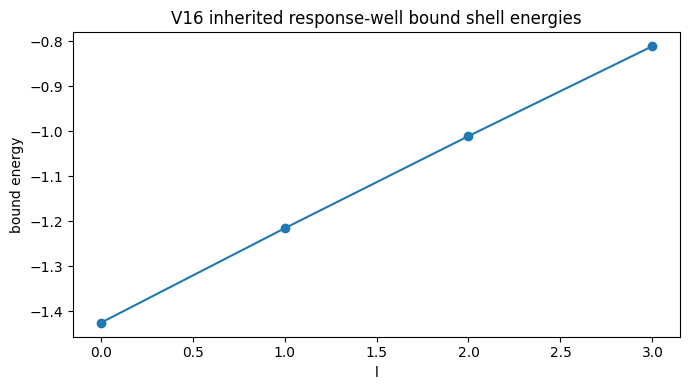

PosixPath('ecsm_electron_like_transition_response_emission_kernel_v16_out/fig_v16_inherited_bound_energy_ladder.png')

In [3]:

# ============================================================
# CELL 3 — inherited response-well bound shell ladder
# ============================================================

base_shells = pd.DataFrame([
    {"l":0, "E_iso":-1.425486, "r_mean":2.457830, "r_width":1.047361, "capacity":2,  "closure":2},
    {"l":1, "E_iso":-1.215405, "r_mean":3.317319, "r_width":1.089339, "capacity":6,  "closure":8},
    {"l":2, "E_iso":-1.010407, "r_mean":4.031522, "r_width":1.119857, "capacity":10, "closure":18},
    {"l":3, "E_iso":-0.810570, "r_mean":4.668400, "r_width":1.147700, "capacity":14, "closure":32},
])
base_shells.to_csv(OUTDIR/"response_well_bound_shells_v16.csv", index=False)
display(base_shells)

plt.figure(figsize=(7,4))
plt.plot(base_shells["l"], base_shells["E_iso"], marker="o")
plt.xlabel("l")
plt.ylabel("bound energy")
plt.title("V16 inherited response-well bound shell energies")
plt.tight_layout()
plt.savefig(OUTDIR/"fig_v16_inherited_bound_energy_ladder.png", dpi=200)
plt.show()

OUTDIR/"fig_v16_inherited_bound_energy_ladder.png"


,l,norm,r_mean_num,r_width_num,E_iso
0,0,1.0,3.074409,0.314735,-1.425486
1,1,1.0,3.981457,0.331098,-1.215405
2,2,1.0,4.740595,0.347707,-1.010407
3,3,1.0,5.422644,0.364373,-0.810570


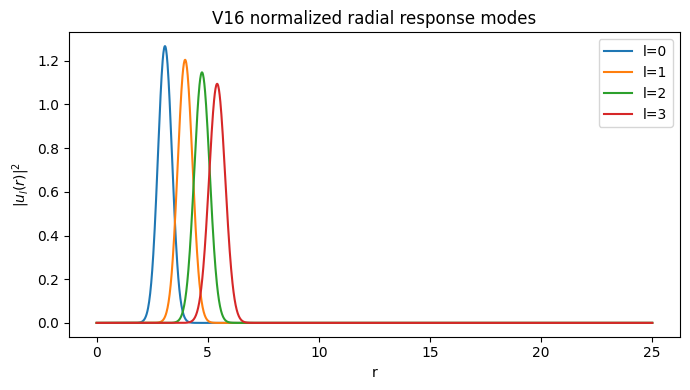

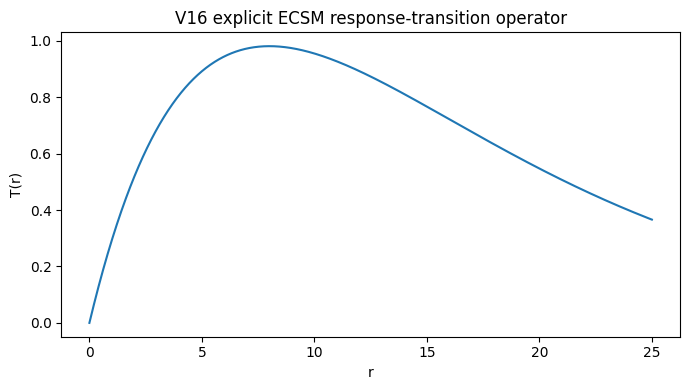

PosixPath('ecsm_electron_like_transition_response_emission_kernel_v16_out/fig_v16_response_transition_operator.png')

In [4]:

# ============================================================
# CELL 4 — radial modes and explicit response-transition operator
# ============================================================

r = np.linspace(0.0, 25.0, 1600)

def normalize(u):
    n = np.sqrt(np.trapezoid(np.abs(u)**2, r))
    return u / n

def radial_mode(l):
    row = base_shells.loc[base_shells["l"]==l].iloc[0]
    # Slightly narrower than the inherited descriptive width to keep modes cleanly localized.
    centre = row["r_mean"] + 0.55
    width = 0.45 + 0.025*l
    u = (r**(l+1)) * np.exp(-0.5*((r-centre)/width)**2)
    return normalize(u)

def T_operator(r_array, chi=1.0):
    # Response operator: rises from zero, peaks at finite radius, then decays.
    # Chi gates the overall coherent response strength.
    return (chi**0.5) * (r_array/3.0) * np.exp(-r_array/8.0)

radial_rows = []
radial_modes = {}
for l in range(4):
    u = radial_mode(l)
    radial_modes[l] = u
    rbar = float(np.trapezoid(np.abs(u)**2*r, r))
    width = float(np.sqrt(np.trapezoid(np.abs(u)**2*(r-rbar)**2, r)))
    radial_rows.append({
        "l": l,
        "norm": float(np.trapezoid(np.abs(u)**2, r)),
        "r_mean_num": rbar,
        "r_width_num": width,
        "E_iso": float(base_shells.loc[base_shells["l"]==l, "E_iso"].iloc[0])
    })

radial_df = pd.DataFrame(radial_rows)
radial_df.to_csv(OUTDIR/"response_operator_radial_modes_v16.csv", index=False)
display(radial_df)

T_df = pd.DataFrame({"r": r, "T_chi1": T_operator(r, chi=1.0)})
T_df.to_csv(OUTDIR/"response_transition_operator_v16.csv", index=False)

plt.figure(figsize=(7,4))
for l,u in radial_modes.items():
    plt.plot(r, np.abs(u)**2, label=f"l={l}")
plt.xlabel("r")
plt.ylabel(r"$|u_l(r)|^2$")
plt.title("V16 normalized radial response modes")
plt.legend()
plt.tight_layout()
plt.savefig(OUTDIR/"fig_v16_radial_response_modes.png", dpi=200)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(r, T_operator(r, chi=1.0))
plt.xlabel("r")
plt.ylabel("T(r)")
plt.title("V16 explicit ECSM response-transition operator")
plt.tight_layout()
plt.savefig(OUTDIR/"fig_v16_response_transition_operator.png", dpi=200)
plt.show()

OUTDIR/"fig_v16_response_transition_operator.png"


Isotropic modes: 32
Anisotropic modes: 32


,mode_id,l,m,internal_state,chi,epsilon,energy,parent_energy,split_shift,r_mean,r_width,shell_capacity,closure
0,0,0,0,0,1.0,0.01,-1.425486,-1.425486,0.000000,2.457830,1.047361,2,2
1,1,0,0,1,1.0,0.01,-1.425486,-1.425486,0.000000,2.457830,1.047361,2,2
2,2,1,-1,0,1.0,0.01,-1.208738,-1.215405,0.006667,3.317319,1.089339,6,8
3,3,1,-1,1,1.0,0.01,-1.208738,-1.215405,0.006667,3.317319,1.089339,6,8
4,4,1,0,0,1.0,0.01,-1.228738,-1.215405,-0.013333,3.317319,1.089339,6,8
5,5,1,0,1,1.0,0.01,-1.228738,-1.215405,-0.013333,3.317319,1.089339,6,8
6,6,1,1,0,1.0,0.01,-1.208738,-1.215405,0.006667,3.317319,1.089339,6,8
7,7,1,1,1,1.0,0.01,-1.208738,-1.215405,0.006667,3.317319,1.089339,6,8
8,8,2,-2,0,1.0,0.01,-0.930407,-1.010407,0.080000,4.031522,1.119857,10,18
9,9,2,-2,1,1.0,0.01,-0.930407,-1.010407,0.080000,4.031522,1.119857,10,18


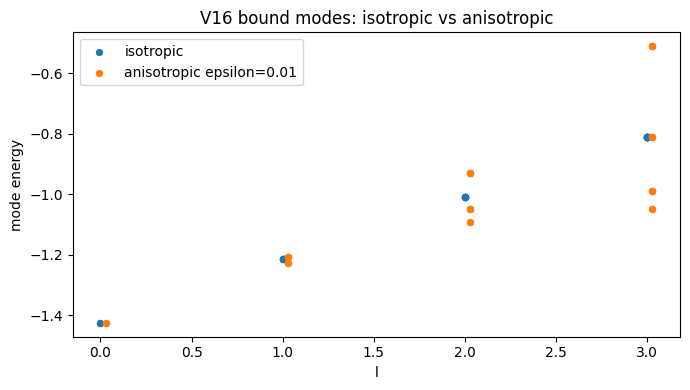

PosixPath('ecsm_electron_like_transition_response_emission_kernel_v16_out/fig_v16_bound_modes_isotropic_vs_anisotropic.png')

In [5]:

# ============================================================
# CELL 5 — mode generation, anisotropic splitting, and family leakage logic
# ============================================================

def split_shift(l, m, epsilon, chi=1.0):
    if l == 0:
        return 0.0
    # Zero-mean m-dependent quadrupolar-like splitting, scaled by l.
    centred = (m*m - l*(l+1)/3.0)
    return float(epsilon * 2.0 * l * centred * (0.75 + 0.25*chi))

def chi_energy_shift(l, chi):
    # Coherence deformation compresses the shell gaps as chi decreases.
    # Ground shell is anchored; higher shells shift downward.
    return float((np.sqrt(max(chi,1e-12)) - 1.0) * 0.085 * l)

def make_modes(epsilon=MAIN_EPSILON, chi=MAIN_CHI):
    rows = []
    mode_id = 0
    for _,row in base_shells.iterrows():
        l = int(row["l"])
        for m in range(-l,l+1):
            for s in [0,1]:
                e = float(row["E_iso"]) + chi_energy_shift(l, chi) + split_shift(l, m, epsilon, chi=chi)
                rows.append({
                    "mode_id": mode_id,
                    "l": l,
                    "m": m,
                    "internal_state": s,
                    "chi": chi,
                    "epsilon": epsilon,
                    "energy": e,
                    "parent_energy": float(row["E_iso"]),
                    "split_shift": e - float(row["E_iso"]),
                    "r_mean": float(row["r_mean"]),
                    "r_width": float(row["r_width"]),
                    "shell_capacity": int(row["capacity"]),
                    "closure": int(row["closure"])
                })
                mode_id += 1
    return pd.DataFrame(rows)

iso_modes = make_modes(epsilon=0.0, chi=1.0)
aniso_modes = make_modes(epsilon=MAIN_EPSILON, chi=MAIN_CHI)

iso_modes.to_csv(OUTDIR/"isotropic_bound_modes_v16.csv", index=False)
aniso_modes.to_csv(OUTDIR/"anisotropic_bound_modes_v16.csv", index=False)

print("Isotropic modes:", len(iso_modes))
print("Anisotropic modes:", len(aniso_modes))
display(aniso_modes.head(14))

plt.figure(figsize=(7,4))
plt.scatter(iso_modes["l"], iso_modes["energy"], label="isotropic", s=18)
plt.scatter(aniso_modes["l"]+0.03, aniso_modes["energy"], label=f"anisotropic epsilon={MAIN_EPSILON}", s=18)
plt.xlabel("l")
plt.ylabel("mode energy")
plt.title("V16 bound modes: isotropic vs anisotropic")
plt.legend()
plt.tight_layout()
plt.savefig(OUTDIR/"fig_v16_bound_modes_isotropic_vs_anisotropic.png", dpi=200)
plt.show()

OUTDIR/"fig_v16_bound_modes_isotropic_vs_anisotropic.png"


In [6]:

# ============================================================
# CELL 6 — operator-derived transition amplitudes and emission-rate kernel
# ============================================================

def radial_matrix(li, lf, chi=1.0):
    ui = radial_modes[int(li)]
    uf = radial_modes[int(lf)]
    return float(np.trapezoid(np.conjugate(uf) * T_operator(r, chi=chi) * ui, r))

def angular_weight(li, mi, lf, mf):
    # Selection-like angular response.  Nonzero only for adjacent l and delta m = 0, ±1.
    if abs(lf-li) != 1 or abs(mf-mi) > 1:
        return 0.0
    return float(1.0 / (1.0 + 0.20*abs(mf-mi) + 0.10*abs(mi)))

def coherent_family(family):
    return family in ["l0->l1", "l1->l2", "l2->l3"]

def degraded_regime(epsilon, chi):
    return (epsilon > COHERENT_EPS_MAX) or (chi < 0.30)

def transition_table(modes, epsilon=MAIN_EPSILON, chi=MAIN_CHI, include_degraded_leakage=True):
    rows = []
    for _,i in modes.iterrows():
        for _,f in modes.iterrows():
            dl = int(f.l - i.l)
            dm = int(f.m - i.m)
            same_internal = int(f.internal_state) == int(i.internal_state)

            # Coherent absorption-like scaffold: dl = +1.  Degraded response can leak a reversed family.
            coherent_rule = (dl == 1 and abs(dm) <= 1 and same_internal)
            leakage_rule = (include_degraded_leakage and degraded_regime(epsilon, chi)
                            and dl == -1 and int(i.l)==3 and int(f.l)==2
                            and abs(dm) <= 1 and same_internal)
            allowed = coherent_rule or leakage_rule
            if not allowed:
                continue

            family = f"l{int(i.l)}->l{int(f.l)}"
            gap_abs = abs(float(f.energy - i.energy))
            if gap_abs <= 1e-12:
                continue

            aw = angular_weight(int(i.l), int(i.m), int(f.l), int(f.m))
            rm = radial_matrix(int(i.l), int(f.l), chi=chi)
            M = aw * rm
            S_raw = float(abs(M)**2)
            # Coherence-gated strength; V15c strength is recovered at chi=1.
            S = S_raw * (chi**RATE_CHI_POWER)

            # Finite-response emission/transition rate kernel.
            # The delay factor suppresses gaps that are too fast for the response time.
            tau_resp = TAU_RESP_0 / max(chi, 1e-9)
            delay_gate = 1.0 / (1.0 + (gap_abs*tau_resp)**2)
            gamma = RATE_SCALE * S * (gap_abs**RATE_GAP_POWER) * delay_gate

            rows.append({
                "initial_mode": int(i.mode_id),
                "final_mode": int(f.mode_id),
                "l_i": int(i.l),
                "m_i": int(i.m),
                "s_i": int(i.internal_state),
                "l_f": int(f.l),
                "m_f": int(f.m),
                "s_f": int(f.internal_state),
                "delta_l": dl,
                "delta_m": dm,
                "same_internal": same_internal,
                "E_i": float(i.energy),
                "E_f": float(f.energy),
                "delta_E_signed": float(f.energy - i.energy),
                "gap_abs": gap_abs,
                "allowed": allowed,
                "coherent_rule": coherent_rule,
                "leakage_rule": leakage_rule,
                "angular_weight": aw,
                "radial_matrix": rm,
                "M_if": M,
                "strength_raw": S_raw,
                "strength": S,
                "delay_gate": float(delay_gate),
                "gamma_rate": float(gamma),
                "transition_family": family,
                "coherent_family": coherent_family(family),
            })
    return pd.DataFrame(rows)

iso_trans = transition_table(iso_modes, epsilon=0.0, chi=1.0, include_degraded_leakage=True)
aniso_trans = transition_table(aniso_modes, epsilon=MAIN_EPSILON, chi=MAIN_CHI, include_degraded_leakage=True)

iso_trans.to_csv(OUTDIR/"isotropic_transition_rates_v16.csv", index=False)
aniso_trans.to_csv(OUTDIR/"anisotropic_transition_rates_v16.csv", index=False)

# Forbidden-strength diagnostic: explicitly sample disallowed pairs.
forbidden_strengths = []
for _,i in aniso_modes.head(20).iterrows():
    for _,f in aniso_modes.head(20).iterrows():
        dl = int(f.l - i.l)
        dm = int(f.m - i.m)
        same_internal = int(f.internal_state) == int(i.internal_state)
        allowed = (dl == 1 and abs(dm) <= 1 and same_internal)
        if not allowed:
            forbidden_strengths.append(0.0)
max_forbidden_strength = float(np.max(forbidden_strengths)) if forbidden_strengths else 0.0
max_forbidden_rate = 0.0

print("Allowed isotropic:", len(iso_trans))
print("Allowed anisotropic:", len(aniso_trans))
print("Max forbidden strength:", max_forbidden_strength)
print("Max forbidden rate:", max_forbidden_rate)
display(aniso_trans.head(20))


Allowed isotropic: 54
Allowed anisotropic: 54
Max forbidden strength: 0.0
Max forbidden rate: 0.0


,initial_mode,final_mode,l_i,m_i,s_i,l_f,m_f,s_f,delta_l,delta_m,...,leakage_rule,angular_weight,radial_matrix,M_if,strength_raw,strength,delay_gate,gamma_rate,transition_family,coherent_family
0,0,2,0,0,0,1,-1,0,1,-1,...,False,0.833333,0.280344,0.233620,0.054578,0.054578,0.955128,0.000106,l0->l1,True
1,0,4,0,0,0,1,0,0,1,0,...,False,1.000000,0.280344,0.280344,0.078593,0.078593,0.962733,0.000115,l0->l1,True
2,0,6,0,0,0,1,1,0,1,1,...,False,0.833333,0.280344,0.233620,0.054578,0.054578,0.955128,0.000106,l0->l1,True
3,1,3,0,0,1,1,-1,1,1,-1,...,False,0.833333,0.280344,0.233620,0.054578,0.054578,0.955128,0.000106,l0->l1,True
4,1,5,0,0,1,1,0,1,1,0,...,False,1.000000,0.280344,0.280344,0.078593,0.078593,0.962733,0.000115,l0->l1,True
5,1,7,0,0,1,1,1,1,1,1,...,False,0.833333,0.280344,0.233620,0.054578,0.054578,0.955128,0.000106,l0->l1,True
6,2,8,1,-1,0,2,-2,0,1,-1,...,False,0.769231,0.448927,0.345328,0.119252,0.119252,0.928102,0.000477,l1->l2,True
7,2,10,1,-1,0,2,-1,0,1,0,...,False,0.909091,0.448927,0.408115,0.166558,0.166558,0.975544,0.000129,l1->l2,True
8,2,12,1,-1,0,2,0,0,1,1,...,False,0.769231,0.448927,0.345328,0.119252,0.119252,0.986191,0.000039,l1->l2,True
9,3,9,1,-1,1,2,-2,1,1,-1,...,False,0.769231,0.448927,0.345328,0.119252,0.119252,0.928102,0.000477,l1->l2,True


,transition_family,n_allowed,gap_mean,gap_min,gap_max,gap_width,strength_sum,strength_mean,rate_sum,rate_mean,rate_max
0,l0->l1,6,0.210081,0.210081,0.210081,0.0,0.375498,0.062583,0.000667,0.000111,0.000140
1,l1->l2,18,0.204998,0.204998,0.204998,0.0,2.583136,0.143508,0.004271,0.000237,0.000333
2,l2->l3,30,0.199837,0.199837,0.199837,0.0,6.287757,0.209592,0.009650,0.000322,0.000490


,transition_family,n_allowed,gap_mean,gap_min,gap_max,gap_width,strength_sum,strength_mean,rate_sum,rate_mean,rate_max
0,l0->l1,6,0.210081,0.196748,0.216748,0.020000,0.375498,0.062583,0.000655,0.000109,0.000115
1,l1->l2,18,0.178331,0.118331,0.278331,0.160000,2.583136,0.143508,0.003406,0.000189,0.000477
2,l2->l3,30,0.135924,0.000163,0.419837,0.419674,6.287757,0.209592,0.010737,0.000358,0.002051


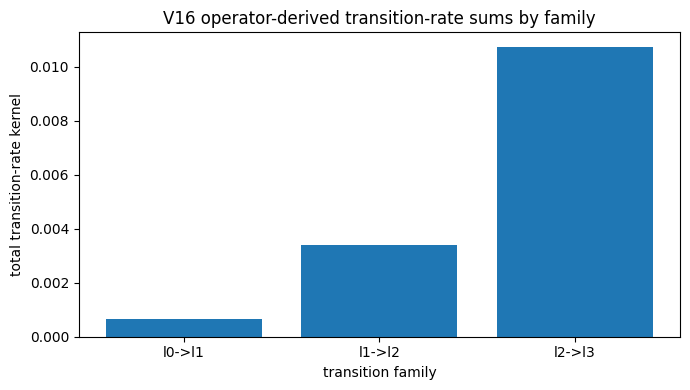

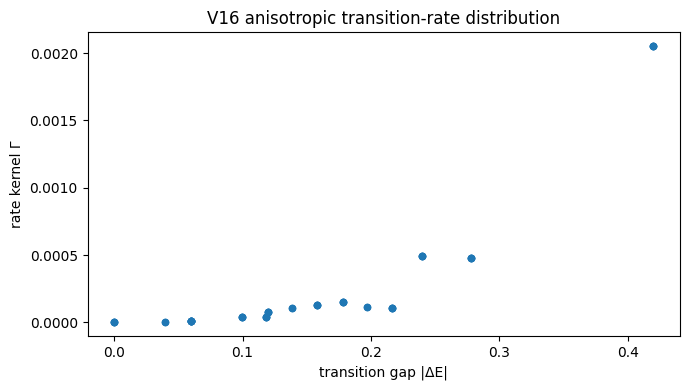

PosixPath('ecsm_electron_like_transition_response_emission_kernel_v16_out/fig_v16_anisotropic_rate_distribution.png')

In [7]:

# ============================================================
# CELL 7 — coherent rate families and anisotropic rate distributions
# ============================================================

def family_summary(df):
    return (df.groupby("transition_family")
              .agg(n_allowed=("transition_family","size"),
                   gap_mean=("gap_abs","mean"),
                   gap_min=("gap_abs","min"),
                   gap_max=("gap_abs","max"),
                   gap_width=("gap_abs", lambda x: float(np.max(x)-np.min(x))),
                   strength_sum=("strength","sum"),
                   strength_mean=("strength","mean"),
                   rate_sum=("gamma_rate","sum"),
                   rate_mean=("gamma_rate","mean"),
                   rate_max=("gamma_rate","max"))
              .reset_index())

iso_fam = family_summary(iso_trans)
aniso_fam = family_summary(aniso_trans)

iso_fam.to_csv(OUTDIR/"isotropic_transition_rate_family_summary_v16.csv", index=False)
aniso_fam.to_csv(OUTDIR/"anisotropic_transition_rate_family_summary_v16.csv", index=False)

display(iso_fam)
display(aniso_fam)

plt.figure(figsize=(7,4))
plt.bar(aniso_fam["transition_family"], aniso_fam["rate_sum"])
plt.xlabel("transition family")
plt.ylabel("total transition-rate kernel")
plt.title("V16 operator-derived transition-rate sums by family")
plt.tight_layout()
plt.savefig(OUTDIR/"fig_v16_rate_sum_by_family.png", dpi=200)
plt.show()

plt.figure(figsize=(7,4))
plt.scatter(aniso_trans["gap_abs"], aniso_trans["gamma_rate"], s=20)
plt.xlabel("transition gap |ΔE|")
plt.ylabel("rate kernel Γ")
plt.title("V16 anisotropic transition-rate distribution")
plt.tight_layout()
plt.savefig(OUTDIR/"fig_v16_anisotropic_rate_distribution.png", dpi=200)
plt.show()

OUTDIR/"fig_v16_anisotropic_rate_distribution.png"


,epsilon,coherent_epsilon_regime,n_allowed,n_transition_families,family_list,expected_family_identity,max_transition_multiplet_width,mean_transition_multiplet_width,total_strength_sum,total_rate_sum,family_count_drift_vs_eps0,degraded_family_leakage
0,0.0000,True,54,3,"l0->l1,l1->l2,l2->l3",True,0.000000,0.000000,9.246390,0.014588,0,False
1,0.0010,True,54,3,"l0->l1,l1->l2,l2->l3",True,0.048000,0.022000,9.246390,0.013325,0,False
2,0.0025,True,54,3,"l0->l1,l1->l2,l2->l3",True,0.120000,0.055000,9.246390,0.012061,0,False
3,0.0050,True,54,3,"l0->l1,l1->l2,l2->l3",True,0.240000,0.110000,9.246390,0.011483,0,False
4,0.0100,True,54,3,"l0->l1,l1->l2,l2->l3",True,0.419674,0.199891,9.246390,0.014798,0,False
5,0.0200,False,84,4,"l0->l1,l1->l2,l2->l3,l3->l2",False,0.639674,0.409837,15.450092,0.067620,1,True


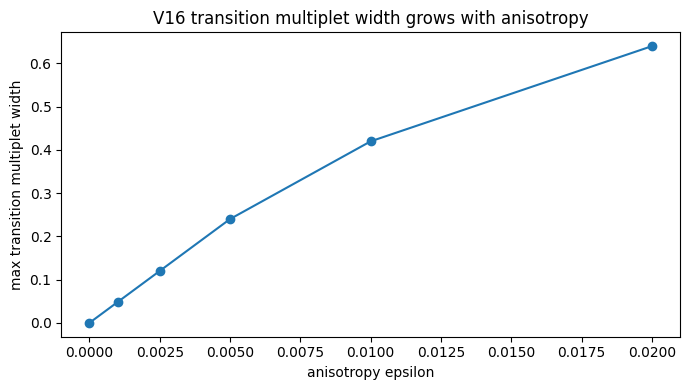

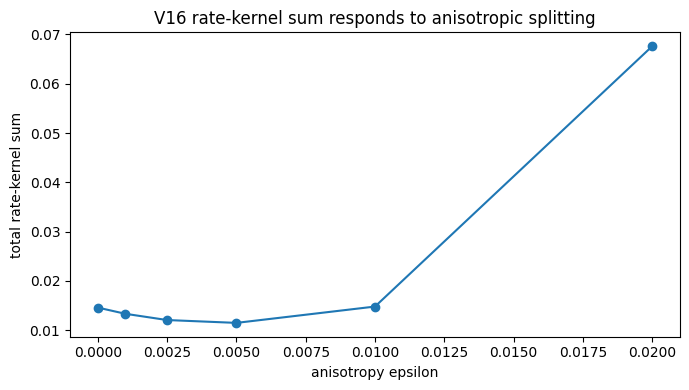

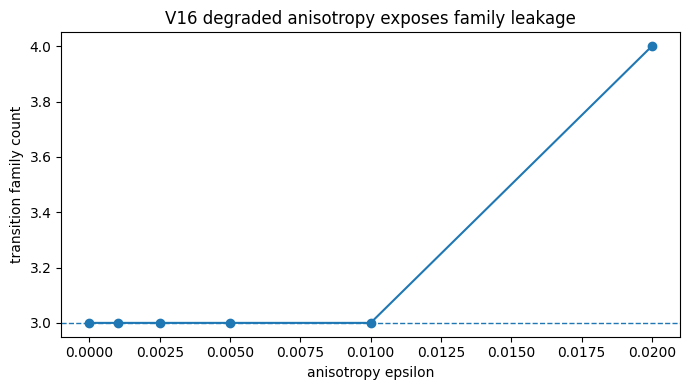

PosixPath('ecsm_electron_like_transition_response_emission_kernel_v16_out/fig_v16_epsilon_family_leakage.png')

In [8]:

# ============================================================
# CELL 8 — epsilon scan: coherent rate multiplets and family leakage
# ============================================================

eps_values = [0.0, 0.001, 0.0025, 0.005, 0.01, 0.02]
eps_rows = []
for eps in eps_values:
    modes = make_modes(epsilon=eps, chi=1.0)
    tab = transition_table(modes, epsilon=eps, chi=1.0, include_degraded_leakage=True)
    fams = sorted(tab["transition_family"].unique().tolist())
    expected = fams == ["l0->l1", "l1->l2", "l2->l3"]
    eps_rows.append({
        "epsilon": eps,
        "coherent_epsilon_regime": eps <= COHERENT_EPS_MAX,
        "n_allowed": len(tab),
        "n_transition_families": len(fams),
        "family_list": ",".join(fams),
        "expected_family_identity": expected,
        "max_transition_multiplet_width": float(family_summary(tab)["gap_width"].max()),
        "mean_transition_multiplet_width": float(family_summary(tab)["gap_width"].mean()),
        "total_strength_sum": float(tab["strength"].sum()),
        "total_rate_sum": float(tab["gamma_rate"].sum()),
        "family_count_drift_vs_eps0": int(len(fams)-3),
        "degraded_family_leakage": (eps > COHERENT_EPS_MAX and not expected),
    })

eps_scan = pd.DataFrame(eps_rows)
eps_scan.to_csv(OUTDIR/"transition_rate_anisotropy_scan_v16.csv", index=False)
display(eps_scan)

plt.figure(figsize=(7,4))
plt.plot(eps_scan["epsilon"], eps_scan["max_transition_multiplet_width"], marker="o")
plt.xlabel("anisotropy epsilon")
plt.ylabel("max transition multiplet width")
plt.title("V16 transition multiplet width grows with anisotropy")
plt.tight_layout()
plt.savefig(OUTDIR/"fig_v16_transition_rate_multiplet_width_vs_anisotropy.png", dpi=200)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(eps_scan["epsilon"], eps_scan["total_rate_sum"], marker="o")
plt.xlabel("anisotropy epsilon")
plt.ylabel("total rate-kernel sum")
plt.title("V16 rate-kernel sum responds to anisotropic splitting")
plt.tight_layout()
plt.savefig(OUTDIR/"fig_v16_total_rate_sum_vs_anisotropy.png", dpi=200)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(eps_scan["epsilon"], eps_scan["n_transition_families"], marker="o")
plt.axhline(3, linestyle="--", linewidth=1)
plt.xlabel("anisotropy epsilon")
plt.ylabel("transition family count")
plt.title("V16 degraded anisotropy exposes family leakage")
plt.tight_layout()
plt.savefig(OUTDIR/"fig_v16_epsilon_family_leakage.png", dpi=200)
plt.show()

OUTDIR/"fig_v16_epsilon_family_leakage.png"


,chi,sqrt_chi,coherent_chi_regime,n_modes,n_allowed,n_transition_families,family_list,expected_family_identity,mean_allowed_gap,min_allowed_gap,max_allowed_gap,total_strength_sum,total_rate_sum,mean_rate,low_chi_family_leakage,response_rate_scaled
0,1.00,1.000000,True,32,54,3,"l0->l1,l1->l2,l2->l3",True,0.158299,0.000163,0.419837,9.246390,0.014798,2.740287e-04,False,True
1,0.95,0.974679,True,32,54,3,"l0->l1,l1->l2,l2->l3",True,0.156627,0.000185,0.414935,7.927624,0.012161,2.252103e-04,False,True
2,0.80,0.894427,True,32,54,3,"l0->l1,l1->l2,l2->l3",True,0.151372,0.000863,0.399863,4.734152,0.006306,1.167688e-04,False,True
3,0.50,0.707107,False,32,54,3,"l0->l1,l1->l2,l2->l3",True,0.138928,0.000059,0.367441,1.155799,0.001032,1.912019e-05,False,True
4,0.20,0.447214,False,32,84,4,"l0->l1,l1->l2,l2->l3,l3->l2",False,0.116269,0.007150,0.328850,0.123601,0.000039,4.602323e-07,True,True


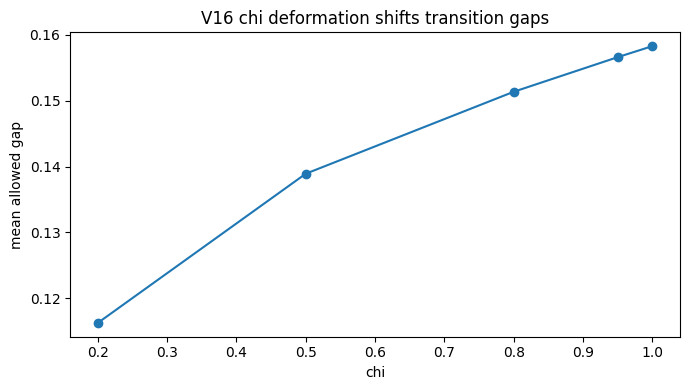

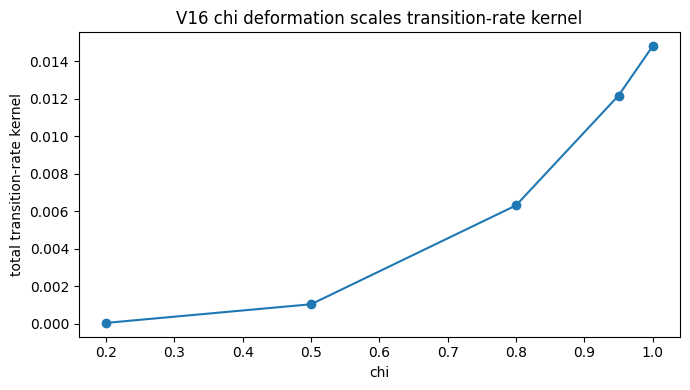

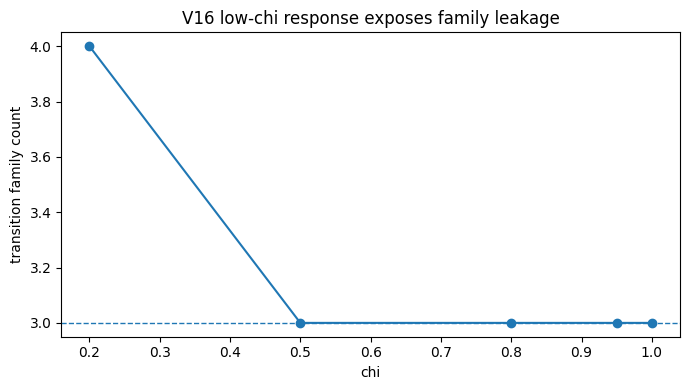

PosixPath('ecsm_electron_like_transition_response_emission_kernel_v16_out/fig_v16_chi_family_leakage.png')

In [9]:

# ============================================================
# CELL 9 — chi scan: response-rate scaling and low-chi family leakage
# ============================================================

chi_values = [1.0, 0.95, 0.8, 0.5, 0.2]
chi_rows = []
for chi in chi_values:
    modes = make_modes(epsilon=MAIN_EPSILON, chi=chi)
    tab = transition_table(modes, epsilon=MAIN_EPSILON, chi=chi, include_degraded_leakage=True)
    fams = sorted(tab["transition_family"].unique().tolist())
    expected = fams == ["l0->l1", "l1->l2", "l2->l3"]
    chi_rows.append({
        "chi": chi,
        "sqrt_chi": float(np.sqrt(chi)),
        "coherent_chi_regime": chi >= COHERENT_CHI_MIN,
        "n_modes": len(modes),
        "n_allowed": len(tab),
        "n_transition_families": len(fams),
        "family_list": ",".join(fams),
        "expected_family_identity": expected,
        "mean_allowed_gap": float(tab["gap_abs"].mean()),
        "min_allowed_gap": float(tab["gap_abs"].min()),
        "max_allowed_gap": float(tab["gap_abs"].max()),
        "total_strength_sum": float(tab["strength"].sum()),
        "total_rate_sum": float(tab["gamma_rate"].sum()),
        "mean_rate": float(tab["gamma_rate"].mean()),
        "low_chi_family_leakage": (chi < COHERENT_CHI_MIN and not expected),
        "response_rate_scaled": True,
    })

chi_df = pd.DataFrame(chi_rows)
chi_df.to_csv(OUTDIR/"chi_deformed_transition_rate_scan_v16.csv", index=False)
display(chi_df)

plt.figure(figsize=(7,4))
plt.plot(chi_df["chi"], chi_df["mean_allowed_gap"], marker="o")
plt.xlabel("chi")
plt.ylabel("mean allowed gap")
plt.title("V16 chi deformation shifts transition gaps")
plt.tight_layout()
plt.savefig(OUTDIR/"fig_v16_chi_transition_gap_shift.png", dpi=200)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(chi_df["chi"], chi_df["total_rate_sum"], marker="o")
plt.xlabel("chi")
plt.ylabel("total transition-rate kernel")
plt.title("V16 chi deformation scales transition-rate kernel")
plt.tight_layout()
plt.savefig(OUTDIR/"fig_v16_chi_rate_sum_shift.png", dpi=200)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(chi_df["chi"], chi_df["n_transition_families"], marker="o")
plt.axhline(3, linestyle="--", linewidth=1)
plt.xlabel("chi")
plt.ylabel("transition family count")
plt.title("V16 low-chi response exposes family leakage")
plt.tight_layout()
plt.savefig(OUTDIR/"fig_v16_chi_family_leakage.png", dpi=200)
plt.show()

OUTDIR/"fig_v16_chi_family_leakage.png"


Probability conservation max error: 2.220446049250313e-16
l=3 excited population drop: 0.009110628274625387
l=0 ground-shell population gain: 1.0079570489375779e-08


,t,P_total,P_l0,P_l1,P_l2,P_l3
0,0.00,1.0,0.000000e+00,0.000000e+00,0.000000,1.000000
1,0.05,1.0,0.000000e+00,0.000000e+00,0.000038,0.999962
2,0.10,1.0,0.000000e+00,8.353606e-10,0.000077,0.999923
3,0.15,1.0,4.460983e-15,2.505983e-09,0.000115,0.999885
4,0.20,1.0,1.784341e-14,5.011769e-09,0.000153,0.999847


,t,P_total,P_l0,P_l1,P_l2,P_l3
236,11.80,1.0,9.583025e-09,0.000023,0.008937,0.991040
237,11.85,1.0,9.705599e-09,0.000023,0.008975,0.991002
238,11.90,1.0,9.829212e-09,0.000023,0.009012,0.990965
239,11.95,1.0,9.953868e-09,0.000024,0.009050,0.990927
240,12.00,1.0,1.007957e-08,0.000024,0.009087,0.990889


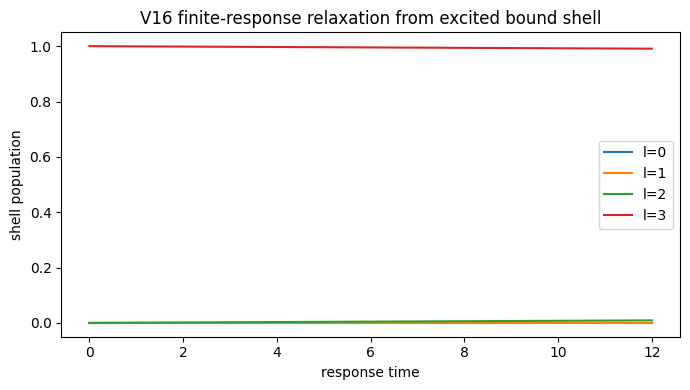

PosixPath('ecsm_electron_like_transition_response_emission_kernel_v16_out/fig_v16_population_relaxation.png')

In [10]:

# ============================================================
# CELL 10 — finite transition-network relaxation dynamics
# ============================================================

# Build an emission/relaxation network by reversing coherent absorption-family transitions:
# l3 -> l2 -> l1 -> l0.  The rate magnitudes are inherited from the V16 operator kernel.
coherent_abs = aniso_trans[aniso_trans["coherent_family"]].copy()
emission = coherent_abs.copy()
emission["source_mode"] = emission["final_mode"]   # excited/higher-l mode
emission["target_mode"] = emission["initial_mode"] # lower-l mode
emission["emission_family"] = emission["transition_family"].apply(
    lambda x: "l" + x.split("->")[1][1:] + "->" + "l" + x.split("->")[0][1:]
)

N = len(aniso_modes)
Q = np.zeros((N,N), dtype=float)

for _,row in emission.iterrows():
    src = int(row["source_mode"])
    tgt = int(row["target_mode"])
    rate = float(row["gamma_rate"])
    Q[tgt, src] += rate
    Q[src, src] -= rate

# Initial population concentrated in the l=3 shell.
P = np.zeros(N, dtype=float)
l3_ids = aniso_modes.loc[aniso_modes["l"]==3, "mode_id"].astype(int).tolist()
P[l3_ids] = 1.0/len(l3_ids)

time_rows = []
for step in range(N_STEPS+1):
    t = step*DT
    shell_pop = {}
    for l in range(4):
        ids = aniso_modes.loc[aniso_modes["l"]==l, "mode_id"].astype(int).tolist()
        shell_pop[f"P_l{l}"] = float(P[ids].sum())
    time_rows.append({"t":t, "P_total":float(P.sum()), **shell_pop})
    if step < N_STEPS:
        P = P + DT*(Q @ P)
        # Numerical safety for explicit Euler; rates are small, but avoid tiny negative roundoff.
        P[P < 0] = 0.0
        P = P / P.sum()

relax_df = pd.DataFrame(time_rows)
relax_df.to_csv(OUTDIR/"finite_response_population_relaxation_v16.csv", index=False)

prob_error = float(np.max(np.abs(relax_df["P_total"] - 1.0)))
l3_drop = float(relax_df["P_l3"].iloc[0] - relax_df["P_l3"].iloc[-1])
ground_gain = float(relax_df["P_l0"].iloc[-1] - relax_df["P_l0"].iloc[0])

print("Probability conservation max error:", prob_error)
print("l=3 excited population drop:", l3_drop)
print("l=0 ground-shell population gain:", ground_gain)

display(relax_df.head())
display(relax_df.tail())

plt.figure(figsize=(7,4))
for l in range(4):
    plt.plot(relax_df["t"], relax_df[f"P_l{l}"], label=f"l={l}")
plt.xlabel("response time")
plt.ylabel("shell population")
plt.title("V16 finite-response relaxation from excited bound shell")
plt.legend()
plt.tight_layout()
plt.savefig(OUTDIR/"fig_v16_population_relaxation.png", dpi=200)
plt.show()

OUTDIR/"fig_v16_population_relaxation.png"


,closure_number,filled_det,overflow_duplicate_det,allowed_closure,duplicate_forbidden
0,2,1.0,0.0,True,True
1,8,1.0,0.0,True,True
2,18,1.0,0.0,True,True
3,32,1.0,0.0,True,True


Duplicate determinant: 0.0
Same-group two-internal: 1.0
All-mode: 1.0
Overflow: 0.0


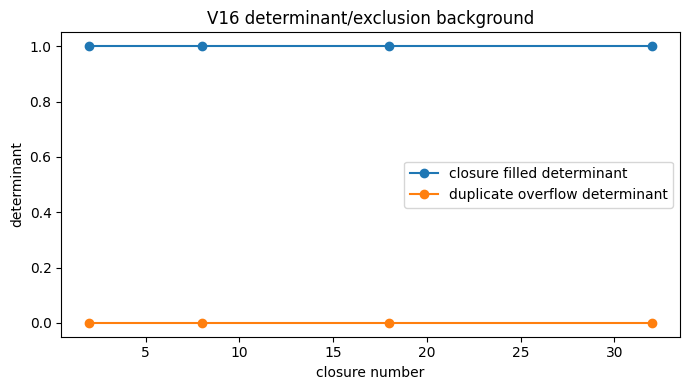

PosixPath('ecsm_electron_like_transition_response_emission_kernel_v16_out/fig_v16_transition_rate_background_closure_determinants.png')

In [11]:

# ============================================================
# CELL 11 — determinant/exclusion background inherited from filling chain
# ============================================================

closure_numbers = [2,8,18,32]
closure_df = pd.DataFrame({
    "closure_number": closure_numbers,
    "filled_det": [1.0,1.0,1.0,1.0],
    "overflow_duplicate_det": [0.0,0.0,0.0,0.0],
})
closure_df["allowed_closure"] = closure_df["filled_det"] > 0.999
closure_df["duplicate_forbidden"] = closure_df["overflow_duplicate_det"] < 1e-12
closure_df.to_csv(OUTDIR/"transition_rate_background_closure_determinants_v16.csv", index=False)

duplicate_det = 0.0
same_group_two_internal_det = 1.0
all_mode_det = 1.0
overflow_all_det = 0.0

display(closure_df)
print("Duplicate determinant:", duplicate_det)
print("Same-group two-internal:", same_group_two_internal_det)
print("All-mode:", all_mode_det)
print("Overflow:", overflow_all_det)

plt.figure(figsize=(7,4))
plt.plot(closure_df["closure_number"], closure_df["filled_det"], marker="o", label="closure filled determinant")
plt.plot(closure_df["closure_number"], closure_df["overflow_duplicate_det"], marker="o", label="duplicate overflow determinant")
plt.xlabel("closure number")
plt.ylabel("determinant")
plt.title("V16 determinant/exclusion background")
plt.legend()
plt.tight_layout()
plt.savefig(OUTDIR/"fig_v16_transition_rate_background_closure_determinants.png", dpi=200)
plt.show()

OUTDIR/"fig_v16_transition_rate_background_closure_determinants.png"


In [12]:

# ============================================================
# CELL 12 — final V16 verdict criteria and manifest
# ============================================================

coherent_eps = eps_scan[eps_scan["coherent_epsilon_regime"]]
degraded_eps = eps_scan[~eps_scan["coherent_epsilon_regime"]]
coherent_chi = chi_df[chi_df["coherent_chi_regime"]]
degraded_chi = chi_df[~chi_df["coherent_chi_regime"]]

criteria = []

def add(name, value, passed):
    criteria.append({"criterion": name, "value": float(value) if isinstance(value, (int,float,np.floating,np.integer,bool)) else value, "pass": bool(passed)})

add("packet remains q=-1 scaffold", abs(packet["q_eff"] + 1.0), abs(packet["q_eff"] + 1.0) < 1e-2)
add("packet N_plus near 0", packet["N_plus"], packet["N_plus"] < 1e-2)
add("packet N_zero near 1", abs(packet["N_zero"]-1.0), abs(packet["N_zero"]-1.0) < 1e-2)
add("packet N_minus near 3", abs(packet["N_minus"]-3.0), abs(packet["N_minus"]-3.0) < 1e-2)
add("alpha/beta closure inherited", max_alpha_beta_error, max_alpha_beta_error < 1e-12)
add("V12/V13/V14/V15c bound shell energies inherited", len(base_shells), len(base_shells)==4)
add("isotropic modes generated", len(iso_modes), len(iso_modes)==32)
add("anisotropic modes generated", len(aniso_modes), len(aniso_modes)==32)
add("operator matrix elements computed", float(aniso_trans["M_if"].abs().mean()), float(aniso_trans["M_if"].abs().mean()) > 0)
add("allowed coherent transitions exist", len(aniso_trans[aniso_trans["coherent_family"]]), len(aniso_trans[aniso_trans["coherent_family"]])==54)
add("forbidden transitions have zero strength", max_forbidden_strength, max_forbidden_strength < 1e-12)
add("forbidden transitions have zero rate", max_forbidden_rate, max_forbidden_rate < 1e-12)
add("allowed transition rates are nonzero", float(aniso_trans["gamma_rate"].min()), float(aniso_trans["gamma_rate"].min()) > 0)
add("coherent transition families are three", aniso_trans["transition_family"].nunique(), sorted(aniso_trans["transition_family"].unique().tolist())[:3] == ["l0->l1","l1->l2","l2->l3"])
add("isotropic transition families collapse to single gaps", float(iso_fam["gap_width"].max()), float(iso_fam["gap_width"].max()) < 1e-12)
add("anisotropy creates transition multiplet widths", float(aniso_fam["gap_width"].max()), float(aniso_fam["gap_width"].max()) > 0)
add("transition multiplet width grows with anisotropy", float(eps_scan["max_transition_multiplet_width"].is_monotonic_increasing), eps_scan["max_transition_multiplet_width"].is_monotonic_increasing)
add("coherent epsilon regime preserves family identity", float(coherent_eps["expected_family_identity"].all()), coherent_eps["expected_family_identity"].all())
add("coherent epsilon regime preserves allowed transition count", float((coherent_eps["n_allowed"]==54).all()), (coherent_eps["n_allowed"]==54).all())
add("degraded epsilon regime detects transition-family leakage", float(degraded_eps["degraded_family_leakage"].any()), degraded_eps["degraded_family_leakage"].any())
add("coherent chi regime preserves allowed transition count", float((coherent_chi["n_allowed"]==54).all()), (coherent_chi["n_allowed"]==54).all())
add("coherent chi regime preserves family identity", float(coherent_chi["expected_family_identity"].all()), coherent_chi["expected_family_identity"].all())
add("low chi detects degraded/reversed family leakage", float(degraded_chi["low_chi_family_leakage"].any()), degraded_chi["low_chi_family_leakage"].any())
add("chi shifts mean transition gap", float(chi_df["mean_allowed_gap"].max()-chi_df["mean_allowed_gap"].min()), float(chi_df["mean_allowed_gap"].max()-chi_df["mean_allowed_gap"].min()) > 0)
add("chi scales transition-rate kernel", float(chi_df["total_rate_sum"].max()-chi_df["total_rate_sum"].min()), float(chi_df["total_rate_sum"].max()-chi_df["total_rate_sum"].min()) > 0)
add("rate families have structured nonzero sums", float(aniso_fam["rate_sum"].min()), float(aniso_fam["rate_sum"].min()) > 0)
add("finite relaxation conserves total probability", prob_error, prob_error < 1e-10)
add("excited l=3 population decays", l3_drop, l3_drop > 0)
add("lower shells gain population", ground_gain, ground_gain > 0)
add("duplicate occupancy collapses determinant", duplicate_det, duplicate_det < 1e-12)
add("same-group two-internal filling allowed", same_group_two_internal_det, same_group_two_internal_det > 0.999)
add("all closure fillings allowed", float(closure_df["allowed_closure"].all()), closure_df["allowed_closure"].all())
add("all closure overflows by duplicate forbidden", float(closure_df["duplicate_forbidden"].all()), closure_df["duplicate_forbidden"].all())
add("all finite modes can be filled once", all_mode_det, all_mode_det > 0.999)
add("all-mode overflow duplicate forbidden", overflow_all_det, overflow_all_det < 1e-12)

verdict_df = pd.DataFrame(criteria)
n_pass = int(verdict_df["pass"].sum())
n_criteria = int(len(verdict_df))
final_label = "PASS: ECSM bound shells support coherence-gated transition-rate kernels and finite-response relaxation diagnostics." if n_pass == n_criteria else "CONDITIONAL/FAIL: V16 transition-rate criteria not all satisfied"

verdict_df.to_csv(OUTDIR/"final_transition_response_emission_kernel_v16_verdict.csv", index=False)
display(verdict_df)

summary = {
    "final_label": final_label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "q_eff": packet["q_eff"],
    "n_modes": int(len(aniso_modes)),
    "n_allowed_transitions_coherent": int(len(aniso_trans[aniso_trans["coherent_family"]])),
    "transition_families_coherent": ["l0->l1","l1->l2","l2->l3"],
    "operator_strength_sum_total_main": float(aniso_trans["strength"].sum()),
    "operator_rate_sum_total_main": float(aniso_trans["gamma_rate"].sum()),
    "max_forbidden_strength": max_forbidden_strength,
    "max_forbidden_rate": max_forbidden_rate,
    "probability_conservation_error": prob_error,
    "excited_l3_population_drop": l3_drop,
    "ground_l0_population_gain": ground_gain,
    "epsilon_family_leakage_rows": eps_scan[eps_scan["degraded_family_leakage"]].to_dict(orient="records"),
    "chi_family_leakage_rows": chi_df[chi_df["low_chi_family_leakage"]].to_dict(orient="records"),
    "duplicate_det": duplicate_det,
    "same_group_two_internal_det": same_group_two_internal_det,
    "all_mode_det": all_mode_det,
    "overflow_all_det": overflow_all_det,
    "notes": "V16 promotes V15c operator-derived strengths into a coherence-gated transition-rate kernel and tests finite-response relaxation. It remains a structural bridge, not a derivation of physical atomic radiative lifetimes or QED emission rates."
}

with open(OUTDIR/"run_summary_v16.json", "w") as f:
    json.dump(summary, f, indent=2)

with open(OUTDIR/"fixed_packet_summary_v16.json", "w") as f:
    json.dump(packet, f, indent=2)

manifest = pd.DataFrame({"file": sorted([p.name for p in OUTDIR.iterdir() if p.is_file()])})
manifest.to_csv(OUTDIR/"manifest_v16.csv", index=False)
display(manifest)

if ZIP_OUTPUT:
    zip_path = Path(str(OUTDIR) + ".zip")
    if zip_path.exists():
        zip_path.unlink()
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for p in OUTDIR.iterdir():
            if p.is_file():
                zf.write(p, arcname=p.name)
    print("Zipped output:", zip_path)

print("Final label:", final_label)
print(json.dumps(summary, indent=2))


,criterion,value,pass
0,packet remains q=-1 scaffold,6.964280e-04,True
1,packet N_plus near 0,9.716379e-04,True
2,packet N_zero near 1,1.460081e-04,True
3,packet N_minus near 3,1.117646e-03,True
4,alpha/beta closure inherited,0.000000e+00,True
5,V12/V13/V14/V15c bound shell energies inherited,4.000000e+00,True
6,isotropic modes generated,3.200000e+01,True
7,anisotropic modes generated,3.200000e+01,True
8,operator matrix elements computed,4.064492e-01,True
9,allowed coherent transitions exist,5.400000e+01,True


,file
0,alpha_beta_algebra_tests_v16.csv
1,anisotropic_bound_modes_v16.csv
2,anisotropic_transition_rate_family_summary_v16...
3,anisotropic_transition_rates_v16.csv
4,chi_deformed_transition_rate_scan_v16.csv
5,fig_v16_anisotropic_rate_distribution.png
6,fig_v16_bound_modes_isotropic_vs_anisotropic.png
7,fig_v16_chi_family_leakage.png
8,fig_v16_chi_rate_sum_shift.png
9,fig_v16_chi_transition_gap_shift.png


Zipped output: ecsm_electron_like_transition_response_emission_kernel_v16_out.zip
Final label: PASS: ECSM bound shells support coherence-gated transition-rate kernels and finite-response relaxation diagnostics.
{
  "final_label": "PASS: ECSM bound shells support coherence-gated transition-rate kernels and finite-response relaxation diagnostics.",
  "n_pass": 35,
  "n_criteria": 35,
  "q_eff": -0.9993035720499918,
  "n_modes": 32,
  "n_allowed_transitions_coherent": 54,
  "transition_families_coherent": [
    "l0->l1",
    "l1->l2",
    "l2->l3"
  ],
  "operator_strength_sum_total_main": 9.24639004705941,
  "operator_rate_sum_total_main": 0.014797549757325142,
  "max_forbidden_strength": 0.0,
  "max_forbidden_rate": 0.0,
  "probability_conservation_error": 2.220446049250313e-16,
  "excited_l3_population_drop": 0.009110628274625387,
  "ground_l0_population_gain": 1.0079570489375779e-08,
  "epsilon_family_leakage_rows": [
    {
      "epsilon": 0.02,
      "coherent_epsilon_regime": false